<a href="https://colab.research.google.com/github/Adhiaris/midterm-machine-learning/blob/main/Regresi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q optuna lime mlflow

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer

import optuna
import lime
import lime.lime_tabular
import mlflow
import mlflow.sklearn

import tensorflow as tf
from tensorflow import keras


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 704.3 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.1 MB/s eta 0:00:00
   

In [ ]:
import pandas as pd
df = pd.read_csv('midterm-regresi-dataset.csv', header=None)
df.columns = ['target'] + [f'feature_{i}' for i in range(1, df.shape[1])]
df.head()
df.isnull().sum().sum()

np.int64(87)

In [ ]:
X = df.drop(columns=['target'])
y = df['target']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

Q1 = np.percentile(X_imputed, 25, axis=0)
Q3 = np.percentile(X_imputed, 75, axis=0)
IQR = Q3 - Q1
mask = ~((X_imputed < (Q1 - 1.5 * IQR)) | (X_imputed > (Q3 + 1.5 * IQR))).any(axis=1)
X_clean = X_imputed[mask]
y_clean = y.values[mask]

X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (70045, 90), Test: (17512, 90)


## Machine Learning Model

In [ ]:
from sklearn.linear_model import Ridge

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    alpha = trial.suggest_float('alpha', 1e-3, 100.0, log=True)
    model = Ridge(alpha=alpha)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    return mean_squared_error(y_test, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

best_alpha = study.best_params['alpha']
print(f"Best alpha: {best_alpha:.4f}")


Best alpha: 0.0010


In [ ]:
mlflow.set_experiment("midterm-regression")

with mlflow.start_run(run_name="Ridge"):
    model = Ridge(alpha=best_alpha)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    mse  = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, preds)
    r2   = r2_score(y_test, preds)

    mlflow.log_param("alpha", best_alpha)
    mlflow.log_metric("MSE",  mse)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("MAE",  mae)
    mlflow.log_metric("R2",   r2)
    mlflow.sklearn.log_model(model, "ridge_model")

pd.DataFrame({'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
              'Value':  [mse, rmse, mae, r2]})


2026/05/16 19:38:14 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/16 19:38:14 INFO mlflow.store.db.utils: Updating database tables
2026/05/16 19:38:16 INFO mlflow.tracking.fluent: Experiment with name 'midterm-regression' does not exist. Creating a new experiment.
2026/05/16 19:38:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/16 19:38:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


,Metric,Value
0,MSE,70.144028
1,RMSE,8.375203
2,MAE,6.048177
3,R²,0.356747


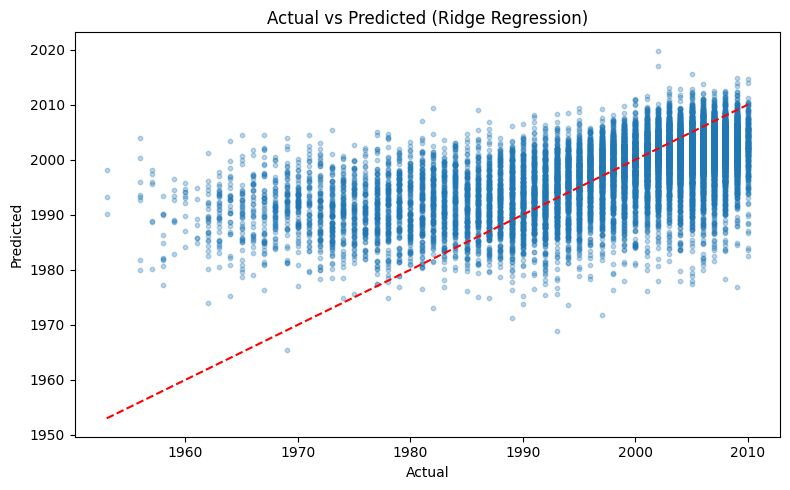

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Ridge Regression)")
plt.tight_layout()
plt.show()


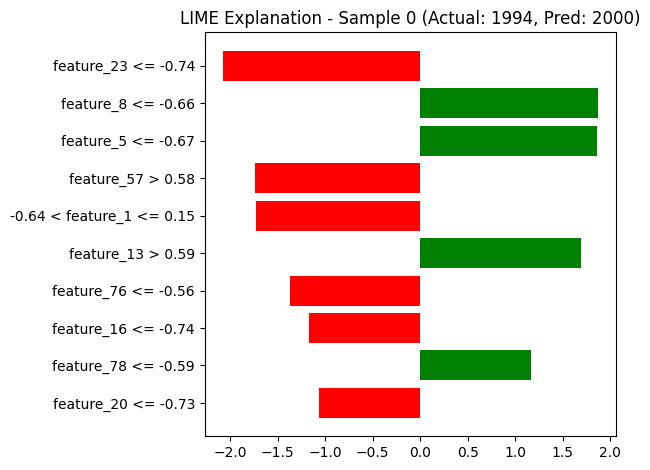

In [ ]:
feature_names = [f'feature_{i}' for i in range(1, X_train_scaled.shape[1]+1)]

explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train_scaled,
    feature_names=feature_names,
    mode='regression'
)

idx = 0
exp = explainer.explain_instance(X_test_scaled[idx], model.predict, num_features=10)
exp.as_pyplot_figure()
plt.title(f"LIME Explanation - Sample {idx} (Actual: {y_test[idx]:.0f}, Pred: {preds[idx]:.0f})")
plt.tight_layout()
plt.show()


## Deep Learning Model

In [ ]:
input_dim = X_train_scaled.shape[1]

dl_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1)
])

dl_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
dl_model.fit(X_train_scaled, y_train, epochs=20, batch_size=512,
             validation_data=(X_test_scaled, y_test), verbose=0)

dl_preds = dl_model.predict(X_test_scaled, verbose=0).flatten()
dl_mse  = mean_squared_error(y_test, dl_preds)
dl_rmse = np.sqrt(dl_mse)
dl_mae  = mean_absolute_error(y_test, dl_preds)
dl_r2   = r2_score(y_test, dl_preds)

with mlflow.start_run(run_name="NeuralNetwork"):
    mlflow.log_param("model", "NeuralNetwork")
    mlflow.log_param("epochs", 20)
    mlflow.log_metric("MSE", dl_mse)
    mlflow.log_metric("RMSE", dl_rmse)
    mlflow.log_metric("MAE", dl_mae)
    mlflow.log_metric("R2", dl_r2)

pd.DataFrame({'Metric': ['MSE', 'RMSE', 'MAE', 'R²'],
              'Value': [dl_mse, dl_rmse, dl_mae, dl_r2]})


,Metric,Value
0,MSE,8705.536133
1,RMSE,93.303463
2,MAE,73.962814
3,R²,-78.833755


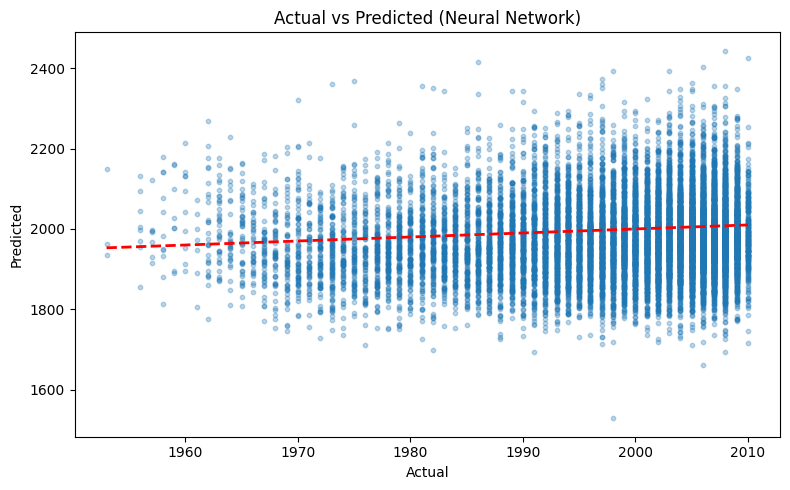

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, dl_preds, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted (Neural Network)")
plt.tight_layout()
plt.show()
